<a href="https://colab.research.google.com/github/MarcelinaBytes/readmission-prediction-ML/blob/main/notebooks/04_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Model Explainability (SHAP)



In [15]:
#Clone my Git

%cd /content
!git clone https://github.com/MarcelinaBytes/readmission-prediction-ML.git
%cd /content/readmission-prediction-ML
import os; os.getcwd()

/content
fatal: destination path 'readmission-prediction-ML' already exists and is not an empty directory.
/content/readmission-prediction-ML


'/content/readmission-prediction-ML'

In [17]:
# Setup and Imports

# Always start in repo root
%cd /content/readmission-prediction-ML

import os
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

os.makedirs('results/shap', exist_ok=True)

print("Working directory:", os.getcwd())


/content/readmission-prediction-ML
Working directory: /content/readmission-prediction-ML


In [18]:
#Load dataset and model

df = pd.read_csv('data/processed/clean_step1.csv')
model = joblib.load('models/best_readmission_model.pkl')

print("Dataset loaded:", df.shape)
print("Model loaded:", type(model))

Dataset loaded: (101766, 48)
Model loaded: <class 'sklearn.pipeline.Pipeline'>


In [19]:
#Extract preprocess and classifier

preprocess = model.named_steps['preprocess']
clf = model.named_steps['clf']

# Verify pipeline pieces
preprocess, clf

(ColumnTransformer(transformers=[('num',
                                  Pipeline(steps=[('scaler',
                                                   StandardScaler(with_mean=False))]),
                                  ['time_in_hospital', 'num_lab_procedures',
                                   'num_procedures', 'num_medications',
                                   'number_outpatient', 'number_emergency',
                                   'number_inpatient']),
                                 ('cat', OneHotEncoder(handle_unknown='ignore'),
                                  ['gender', 'age', 'admission_type_id',
                                   'discharge_disposition_id',
                                   'admission_source_id', 'insulin'])]),
 XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.8, device=None, early_stopping_rounds=None,
               enable_categorical=Fal

In [20]:
#Prepare transformed data

# Use the same feature columns the pipeline was trained on
feature_cols = preprocess.feature_names_in_
X = df[feature_cols]

# Transform into numeric matrix (model-ready)
X_transformed = preprocess.transform(X)

# Expanded feature names (after one-hot encoding)
feature_names = preprocess.get_feature_names_out()

len(feature_names)

74

##Global Explainability


In [21]:
#SHAP TreeExplainer

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_transformed)

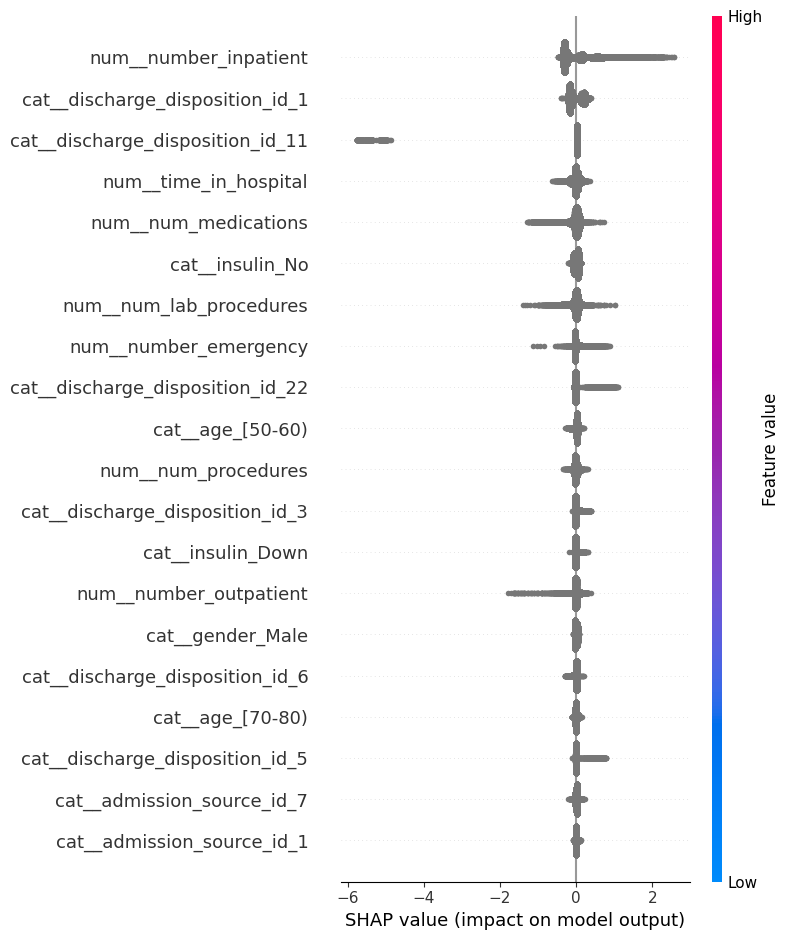

In [22]:
#SHAP Beeswarm (global importance)

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, show=False)
plt.tight_layout()
plt.savefig('results/shap/summary_beeswarm.png', dpi=150)
plt.show()

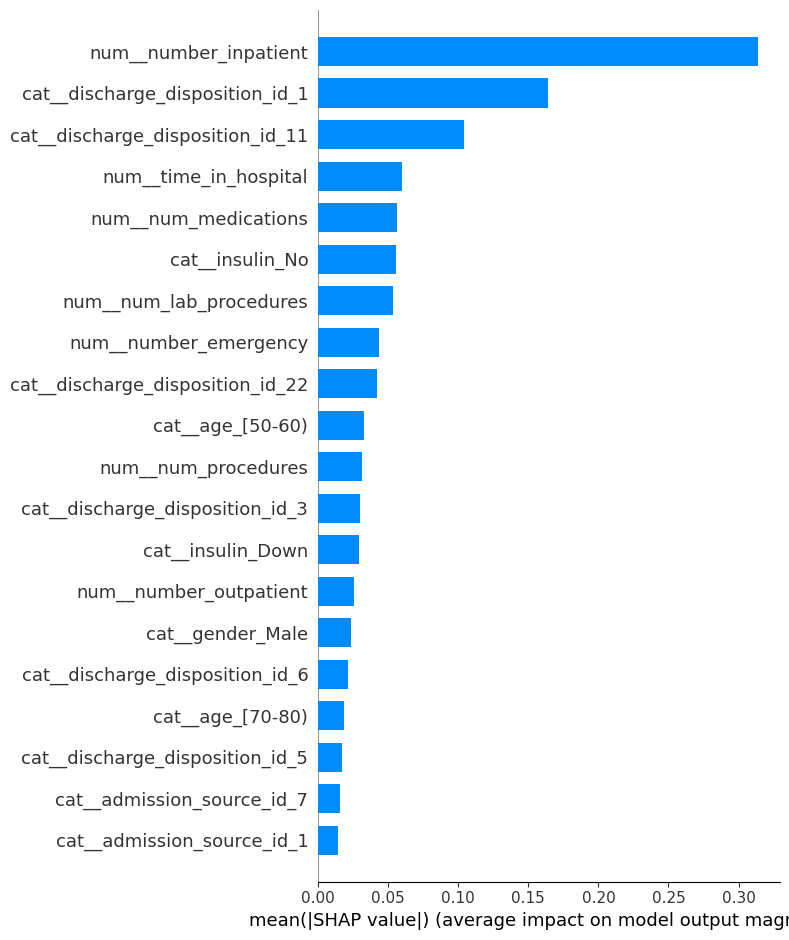

In [23]:
#SHAP Bar Plot

plt.figure(figsize=(10,6))
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('results/shap/summary_bar.png', dpi=150)
plt.show()

##Local (Individual Patient) Explainability

In [24]:
#Pick a random patient

i = np.random.randint(0, X_transformed.shape[0])
i

76636

In [26]:
#SHAP Force Plot

shap.initjs()

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_transformed[i].toarray() if hasattr(X_transformed[i], "toarray") else X_transformed[i],
    feature_names=feature_names
)